# Transfer Learning

🎯 **Goal**: Improve classification performance by leveraging a pretrained convolutional neural network as a feature extractor.

**Approach**:

- Use MobileNetV2 pretrained on ImageNet as the base model
- Freeze the pretrained layers to retain learned visual features
- Add a lightweight classification head for the bird species task
- Train only the new top layers initially
- Evaluate performance against the baseline and log results using MLflow

### Executive Summary

This project explores bird species classification across 200 fine-grained classes using deep learning.

A baseline CNN performs poorly (~2% accuracy), confirming that training from scratch is insufficient for this task. Transfer learning dramatically improves performance, with MobileNetV2 reaching ~50% accuracy.

Further experiments show that regularisation techniques such as data augmentation and fine-tuning provide only marginal gains. The most significant improvement comes from backbone choice: EfficientNetB0 achieves ~65% validation accuracy and ~67% test accuracy.

👉 Overall, results demonstrate that high-quality pretrained feature extractors are critical for fine-grained image classification, and that backbone selection has a far greater impact than incremental training tweaks.

### Imports

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from beakspeak.data import load_metadata, split_data, create_dataset
from beakspeak.params import (
    IMG_HEIGHT,
    IMG_WIDTH,
    BATCH_SIZE,
    EPOCHS,
    LEARNING_RATE,
    SEED,
    NUM_CLASSES,
)

# --- MLFlow setup ---
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlruns.db")
MLFLOW_EXPERIMENT_NAME = "beakspeak-transfer"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

# --- Paths ---
DATA_DIR = Path("../data/CUB_200_2011/CUB_200_2011")

# --- tf performance ---
AUTOTUNE = tf.data.AUTOTUNE

# --- Checks ---
print("cwd:", os.getcwd())
print("tracking uri:", mlflow.get_tracking_uri())
print("resolved tracking path:", (Path.cwd() / "../mlruns").resolve())

cwd: /Users/keira/Documents/projects/beakspeak/notebooks
tracking uri: sqlite:///../mlruns.db
resolved tracking path: /Users/keira/Documents/projects/beakspeak/mlruns


In [2]:
# --- MLFlow helper function to plot and log curves ---

def plot_and_log_curves(history):
    import matplotlib.pyplot as plt
    import mlflow

    # --- extract metrics ---
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))

    # --- Accuracy plot ---
    plt.figure()
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.savefig("accuracy_curve.png")
    mlflow.log_artifact("accuracy_curve.png")
    plt.close()

    # --- Loss plot ---
    plt.figure()
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.savefig("loss_curve.png")
    mlflow.log_artifact("loss_curve.png")
    plt.close()

In [3]:
### --- MLFlow helper function to log consistent parameters ---

def log_run_params(
    backbone,
    stage,
    frozen_base,
    learning_rate,
    epochs,
    early_stopping=False,
    early_stopping_patience=None,
    batchnorm_frozen=None,
    fine_tune_at=None,
    augmentation=None,
):
    """
    Log a consistent set of MLflow parameters for model runs.
    Optional params are only logged when relevant.
    """
    params = {
        "backbone": backbone,
        "stage": stage,
        "frozen_base": frozen_base,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "early_stopping": early_stopping,
        "early_stopping_patience": early_stopping_patience,
    }

    # Only include optional params if relevant
    if batchnorm_frozen is not None:
        params["batchnorm_frozen"] = batchnorm_frozen

    if fine_tune_at is not None:
        params["fine_tune_at"] = fine_tune_at

    if augmentation is not None:
        params["augmentation"] = augmentation


    mlflow.log_params(params)

## Load the data

In [4]:
# Load and split the data
metadata_df = load_metadata(DATA_DIR)
train_df, val_df, test_df = split_data(metadata_df)

In [5]:
# Prepare labels for tf
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

In [6]:
# Create train, test, val datasets
train_ds = create_dataset(train_df, shuffle=True, scaling=False)
val_ds = create_dataset(val_df, shuffle=False, scaling=False)
test_ds = create_dataset(test_df, shuffle=False, scaling=False)

## Working with MobileNetV2

### 🙋‍♀️ Why MobileNetV2

MobileNetV2 is a lightweight, widely used convolutional neural network pretrained on ImageNet, making it a strong starting point for transfer learning.

It is well-suited for this task because:
- it has already learned general visual features (edges, textures, shapes, object structure)
- it performs well on image classification tasks while remaining computationally efficient
- it is designed for input sizes of 224x224, aligning with the current preprocessing pipeline
- it provides a clear and interpretable step-up from the baseline CNN

Using MobileNetV2 allows us to test the impact of transfer learning in a clean and controlled way, before exploring more complex models or fine-tuning strategies.

In [ ]:
def build_transfer_learning_model(num_classes, backbone="MobileNetV2", use_augmentation=False):
    """
    Build a transfer learning model using a specified backbone as the feature extractor.

    Args:
        num_classes (int): Number of output classes for classification.
        backbone (str): Which pretrained model to use as the base (e.g., "MobileNetV2", "EfficientNetB0", "ResNet50").
        use_augmentation (bool): Whether to include data augmentation layers in the model.
    """

    backbone = backbone.lower()

    # Load the specified backbone with pretrained ImageNet weights
    if backbone == "mobilenetv2":
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
            include_top=False,
            weights="imagenet"
        )
    elif backbone == "efficientnetb0":
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
            include_top=False,
            weights="imagenet"
        )

    elif backbone == "resnet50":
        base_model = tf.keras.applications.ResNet50(
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
            include_top=False,
            weights="imagenet"
        )

    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    # Freeze the base model
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = inputs

    # Optional augmentation layer
    if use_augmentation:
        x = data_augmentation(x)

    # Preprocessing specific to the backbone
    if backbone == "efficientnetb0":
        x = tf.keras.applications.efficientnet.preprocess_input(x)
    elif backbone == "mobilenetv2":
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    elif backbone == "resnet50":
        x = tf.keras.applications.resnet50.preprocess_input(x)

    # Pass through the base model
    x = base_model(x, training=False)

    # Custom classification head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)         # Reduce spatial dimensions
    x = tf.keras.layers.Dense(128, activation="relu")(x)    # Learn complex patterns
    x = tf.keras.layers.Dropout(0.3)(x)                     # Regularization
    outputs = tf.keras.layers.Dense(num_classes)(x)

     # Create the model
    model = tf.keras.Model(inputs, outputs)

    return model

In [9]:
# Build and compile the model
transfer_model = build_transfer_learning_model(NUM_CLASSES)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,447,752 (9.34 MB)

 Trainable params: 189,768 (741.28 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Train the model and log metrics to MLflow

with mlflow.start_run(run_name="mobilenetv2_frozen_initial"):
    log_run_params(
        backbone="MobileNetV2",
        stage="frozen_initial",
        frozen_base=True,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        early_stopping=False,
    )

    history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    plot_and_log_curves(history)

    val_loss, val_acc = transfer_model.evaluate(val_ds)
    test_loss, test_acc = transfer_model.evaluate(test_ds)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_acc)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 215ms/step - accuracy: 0.0588 - loss: 4.7414 - val_accuracy: 0.1952 - val_loss: 3.6109
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 213ms/step - accuracy: 0.2186 - loss: 3.2154 - val_accuracy: 0.3394 - val_loss: 2.7367
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 232ms/step - accuracy: 0.3466 - loss: 2.4875 - val_accuracy: 0.4020 - val_loss: 2.3419
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.4461 - loss: 2.0795 - val_accuracy: 0.4445 - val_loss: 2.1425
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.5066 - loss: 1.7860 - val_accuracy: 0.4470 - val_loss: 2.0527
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.4470 - loss: 2.0527
182/182 ━━━━━━━━━━━━━━━━━━━━ 33s 183ms/step - accuracy: 0.4658 - loss: 2.0288
Validation Accuracy: 0.4470
Test Accuracy: 0.4658


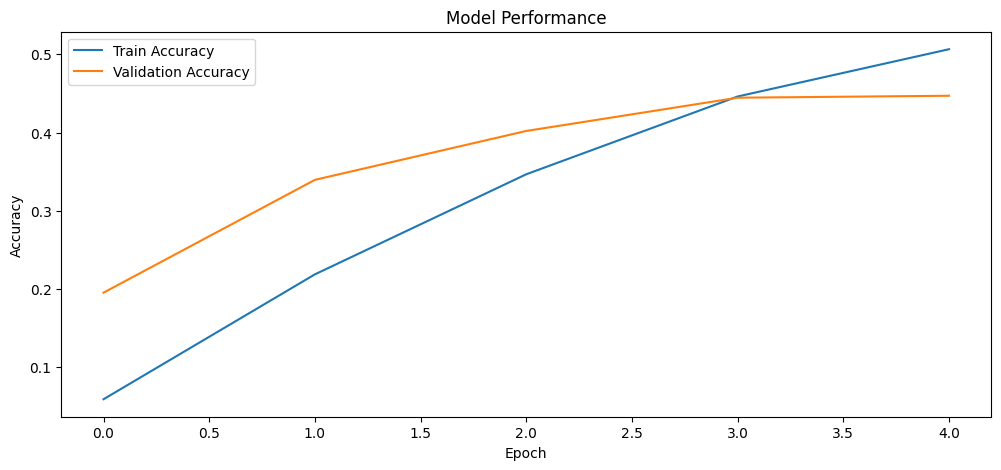

In [11]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Performance")
plt.legend()
plt.show()

🙋‍♀️ **What next?**

The transfer learning model dramatically outperforms the baseline, reaching ~45% validation accuracy and ~47% test accuracy after 5 epochs (vs ~2% baseline).

The model shows strong, consistent learning:

- Training accuracy increases steadily (~6% → ~51%)
- Validation accuracy improves each epoch (~20% → ~45%)
- Validation loss continues to decrease

Importantly, no meaningful overfitting yet — train and validation curves are close and move together.

This confirms that the pretrained MobileNetV2 backbone provides highly transferable visual features, which are essential for fine-grained classification. Despite a relatively small classification head, it massively outperforms the baseline CNN, reinforcing that feature quality > parameter count.

👉 Since validation performance is still improving at the end of training, the next step is **extend training with early stopping**.

----

(*) *The baseline model had more trainable parameters largely because Flatten + Dense layers are parameter-heavy, whereas the transfer model uses a frozen pretrained backbone plus a compact classification head.*

### MobileNetV2 + Extended Training

Epochs 🔼

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

with mlflow.start_run(run_name="mobilenetv2_frozen_es"):
    log_run_params(
        backbone="MobileNetV2",
        stage="frozen_extended",
        frozen_base=True,
        learning_rate=LEARNING_RATE,
        epochs=15,
        early_stopping=True,
        early_stopping_patience=3,
    )

    history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(history)

    val_loss, val_acc = transfer_model.evaluate(val_ds)
    test_loss, test_acc = transfer_model.evaluate(test_ds)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_acc)

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_loss", test_loss)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - accuracy: 0.5652 - loss: 1.5826 - val_accuracy: 0.4646 - val_loss: 1.9799
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 39s 262ms/step - accuracy: 0.5983 - loss: 1.4101 - val_accuracy: 0.4762 - val_loss: 1.9433
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 264ms/step - accuracy: 0.6384 - loss: 1.2716 - val_accuracy: 0.4804 - val_loss: 1.9326
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 253ms/step - accuracy: 0.6686 - loss: 1.1414 - val_accuracy: 0.4879 - val_loss: 1.8887
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - accuracy: 0.6997 - loss: 1.0308 - val_accuracy: 0.5088 - val_loss: 1.9304
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 238ms/step - accuracy: 0.7260 - loss: 0.9514 - val_accuracy: 0.4962 - val_loss: 1.9192
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 358ms/step - accuracy: 0.7539 - loss: 0.8468 - val_accuracy: 0.5063 - val_loss: 1.8833
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.7862 - loss: 0

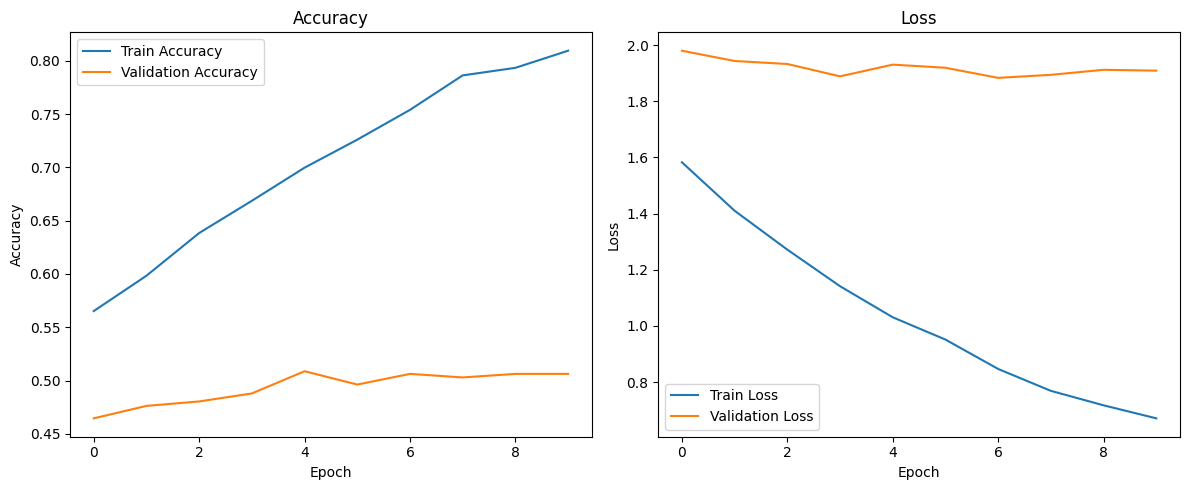

In [13]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 💡 Transfer Learning (Extended Training) - Performance & Interpretation

Extending training beyond the initial 5-epoch run leads to further improvements, with validation accuracy reaching ~51% and test accuracy ~51.3% (up from ~45–47%).

Early epochs show consistent gains, confirming the model was still learning beyond the initial 5 epochs.

However, from around epoch 5 onwards:

- Validation accuracy plateaus (~50–51%)
- Validation loss stops improving
- Training accuracy continues rising to ~81%

This is clear overfitting — the model is memorising training data without improving generalisation. Early stopping correctly halts training and restores the best weights.

Key takeaway:
- Transfer learning is working well
- Frozen backbone has hit its ceiling

👉 The next step is to increase model flexibility by fine-tuning the upper layers of MobileNetV2, allowing the feature extractor to adapt to the fine-grained differences between bird species.

## MobileNet Fine-Tuning

The previous experiments show that transfer learning provides a strong foundation, but performance plateaus when the pretrained backbone is frozen.

To improve further, the model needs to adapt its feature representations to the specific characteristics of the dataset. This is particularly important for fine-grained classification tasks, where subtle visual differences matter.

In this step, the upper layers of MobileNetV2 are unfrozen and trained with a lower learning rate, allowing the model to refine its features without disrupting the pretrained weights.

In [14]:
# Show the top-level layers in the transfer model
for i, layer in enumerate(transfer_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_1 True
1 mobilenetv2_1.00_224 False
2 global_average_pooling2d True
3 dense True
4 dropout True
5 dense_1 True


In [15]:
# Access pre-trained base model layers
base_model = transfer_model.layers[1]

print(base_model.name)
print("Number of layers in base model:", len(base_model.layers))

mobilenetv2_1.00_224
Number of layers in base model: 154


In [16]:
# Unfreeze the base model
base_model.trainable = True

# Selectively unfreeze layers to fine-tune
fine_tune_at = len(base_model.layers) - 30

# Freeze all layers before the fine-tune point
for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        # Keep BatchNorm layers frozen to prevent training instability
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Confirm trainable status of last few layers
for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

# Count trainable vs non-trainable weights
print("Trainable weights:", len(transfer_model.trainable_weights))
print("Non-trainable weights:", len(transfer_model.non_trainable_weights))

block_16_expand_BN False
block_16_expand_relu True
block_16_depthwise True
block_16_depthwise_BN False
block_16_depthwise_relu True
block_16_project True
block_16_project_BN False
Conv_1 True
Conv_1_bn False
out_relu True
Trainable weights: 14
Non-trainable weights: 250


In [17]:
# Recompile the model with a lower learning rate for fine-tuning
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_EPOCHS = 15

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Early stopping callback for fine-tuning
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Set up MLflow for fine-tuning run
with mlflow.start_run(run_name="mobilenetv2_finetune_top30"):
    log_run_params(
        backbone="MobileNetV2",
        stage="finetune_top30",
        frozen_base=False,
        learning_rate=FINE_TUNE_LEARNING_RATE,
        epochs=FINE_TUNE_EPOCHS,
        early_stopping=True,
        early_stopping_patience=3,
        batchnorm_frozen=True,
        fine_tune_at=fine_tune_at,
    )

    # Train the model with fine-tuning and early stopping
    fine_tune_history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(fine_tune_history)

    # Evaluate the model on validation and test sets
    val_loss, val_accuracy = transfer_model.evaluate(val_ds, verbose=0)
    test_loss, test_accuracy = transfer_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)

    best_val_accuracy = max(fine_tune_history.history["val_accuracy"])
    best_val_loss = min(fine_tune_history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 337ms/step - accuracy: 0.7987 - loss: 0.6885 - val_accuracy: 0.5054 - val_loss: 1.9026
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 309ms/step - accuracy: 0.8088 - loss: 0.6340 - val_accuracy: 0.5138 - val_loss: 1.8936
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 310ms/step - accuracy: 0.8257 - loss: 0.5893 - val_accuracy: 0.5196 - val_loss: 1.8956
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 310ms/step - accuracy: 0.8375 - loss: 0.5603 - val_accuracy: 0.5196 - val_loss: 1.9068
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.8515 - loss: 0.5166 - val_accuracy: 0.5229 - val_loss: 1.8961
Validation Accuracy: 0.5138
Test Accuracy: 0.5243
Best Validation Accuracy: 0.5229
Best Validation Loss: 1.8936


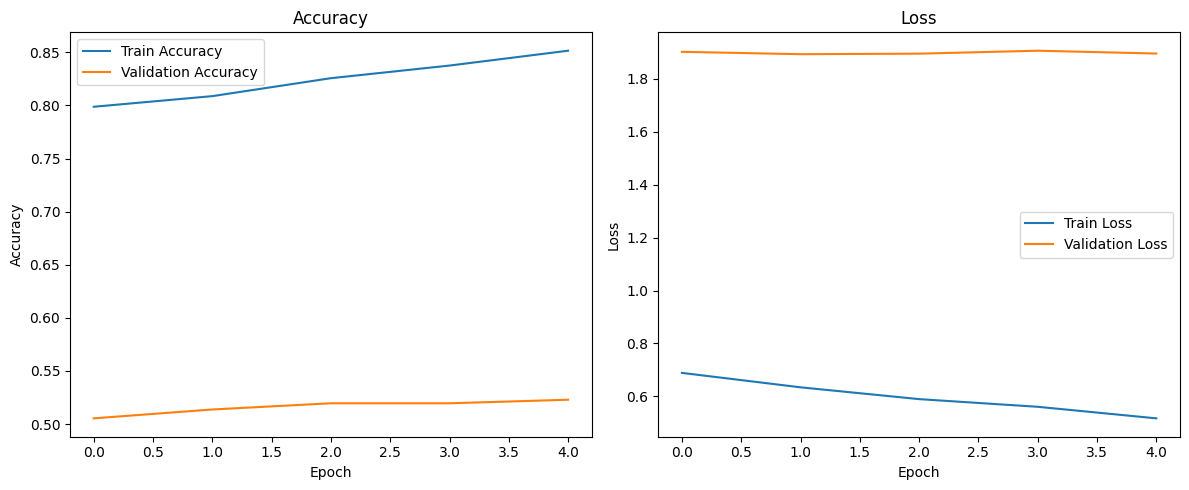

In [18]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = fine_tune_history.history["accuracy"]
val_acc = fine_tune_history.history["val_accuracy"]

loss = fine_tune_history.history["loss"]
val_loss = fine_tune_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 🙋‍♀️ Fine-tuning: small gain, overfitting still present

Fine-tuning MobileNetV2 gives a modest improvement over the frozen model, with best validation accuracy reaching ~52.3% and test accuracy ~52.4%.

However, the overall pattern is largely unchanged:

- Training accuracy continues to rise (~80% → ~85%)
- Validation accuracy improves only slightly and then starts to plateau
- Validation loss stays almost flat

This suggests that ****fine-tuning helps a little, but does not meaningfully solve the generalisation problem**. Overfitting is still present, and gains are now diminishing.

Before switching architectures, I want to test whether this can be reduced through **data augmentation**. If augmentation improves generalisation, it suggests the current backbone is viable but the model needs stronger regularisation. If not, that points more clearly to backbone choice as the next lever.

## MobileNet with data augmentation

In [19]:
# Simple image augmentation for training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # Randomly flip images horizontally
    tf.keras.layers.RandomRotation(0.05),       # Randomly rotate images by up to 5%
    tf.keras.layers.RandomZoom(0.1)             # Randomly zoom images by up to 10%
])

# Build and compile a new model with augmentation
transfer_aug_model = build_transfer_learning_model(
    num_classes=NUM_CLASSES,
    use_augmentation=True
)

transfer_aug_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

transfer_aug_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,447,752 (9.34 MB)

 Trainable params: 189,768 (741.28 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Early stopping callback for augmentation training
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model with augmentation and log metrics to MLflow
with mlflow.start_run(run_name="mobilenetv2_frozen_aug"):

    log_run_params(
        backbone="MobileNetV2",
        stage="frozen_aug",
        frozen_base=True,
        learning_rate=LEARNING_RATE,
        epochs=15,
        early_stopping=True,
        early_stopping_patience=3,
        augmentation=True,
    )

    transfer_aug_history = transfer_aug_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(transfer_aug_history)

    val_loss, val_acc = transfer_aug_model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = transfer_aug_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("best_val_accuracy", max(transfer_aug_history.history["val_accuracy"]))
    mlflow.log_metric("best_val_loss", min(transfer_aug_history.history["val_loss"]))

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Best Validation Accuracy: {max(transfer_aug_history.history['val_accuracy']):.4f}")
    print(f"Best Validation Loss: {min(transfer_aug_history.history['val_loss']):.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.0400 - loss: 4.9609 - val_accuracy: 0.1501 - val_loss: 4.0551
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 301ms/step - accuracy: 0.1579 - loss: 3.6940 - val_accuracy: 0.2744 - val_loss: 3.0283
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 309ms/step - accuracy: 0.2621 - loss: 3.0068 - val_accuracy: 0.3628 - val_loss: 2.6198
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 335ms/step - accuracy: 0.3233 - loss: 2.6066 - val_accuracy: 0.3862 - val_loss: 2.3592
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.3708 - loss: 2.3434 - val_accuracy: 0.4254 - val_loss: 2.2296
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 340ms/step - accuracy: 0.4127 - loss: 2.1282 - val_accuracy: 0.4279 - val_loss: 2.1453
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 321ms/step - accuracy: 0.4607 - loss: 2.0002 - val_accuracy: 0.4587 - val_loss: 2.0766
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 336ms/step - accuracy: 0.4709 - loss: 1

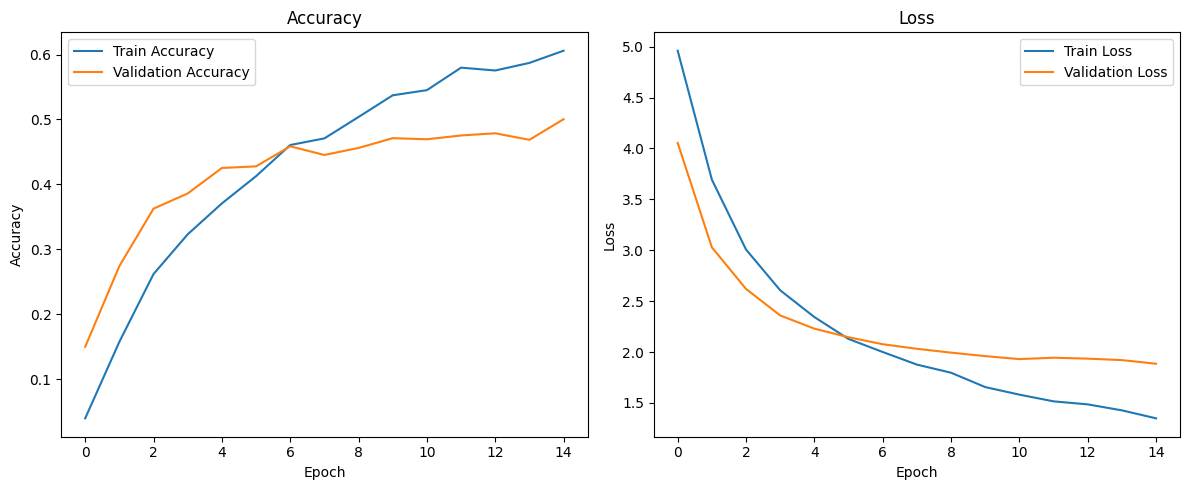

In [21]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = transfer_aug_history.history["accuracy"]
val_acc = transfer_aug_history.history["val_accuracy"]

loss = transfer_aug_history.history["loss"]
val_loss = transfer_aug_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 🙋‍♀️ Data augmentation: limited benefit

*Adding data augmentation does not improve overall performance relative to the best frozen MobileNetV2 run.*

This model reaches:
 
 - 50.0% validation accuracy
 - 49.1% test accuracy

That is slightly worse than the non-augmented extended run (~50.9% best val, ~51.3% test).

The learning curves do show one useful effect: augmentation slows memorisation and narrows the train/validation gap compared with the non-augmented model. So it provides some regularisation benefit.

But the headline result is that augmentation does not unlock better generalisation here. Performance still plateaus around 50%, suggesting the main bottleneck is not lack of input variation.

Instead, the dominant constraint appears to be the representational capacity of the model for this fine-grained classification task. Further improvements are more likely to come from stronger backbones or more targeted model adaptation than from additional regularisation alone.

👉 **Next step** = Try to capture finer visual details with EfficientNetB0

*Does a stronger backbone improve validation accuracy without needing heavy regularisation?*

## EfficientNetB0

Previous experiments suggest that regularisation techniques such as early stopping and data augmentation provide only incremental improvements, with the core limitation appearing to be model generalisation.

This experiment tests whether a stronger pretrained backbone (EfficientNetB0) can provide more discriminative features for this fine-grained classification task, improving validation performance beyond what was achieved with MobileNetV2.

In [22]:
# Build and compile EfficientNetB0 model
efficient_model = build_transfer_learning_model(
    num_classes=NUM_CLASSES,
    backbone="EfficientNetB0",
    use_augmentation=False
)

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

efficient_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,239,339 (16.17 MB)

 Trainable params: 189,768 (741.28 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
# Train the EfficientNetB0 model and log metrics to MLflow
with mlflow.start_run(run_name="efficientnetb0_frozen_initial"):
    log_run_params(
        backbone="EfficientNetB0",
        stage="frozen_initial",
        frozen_base=True,
        learning_rate=LEARNING_RATE,
        epochs=15,
        early_stopping=True,
        early_stopping_patience=3
    )

    efficient_history = efficient_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(efficient_history)

    val_loss, val_acc = efficient_model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = efficient_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_acc)

    best_val_accuracy = max(efficient_history.history["val_accuracy"])
    best_val_loss = min(efficient_history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.5487 - loss: 1.6544 - val_accuracy: 0.5413 - val_loss: 1.6599
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 323ms/step - accuracy: 0.5952 - loss: 1.4375 - val_accuracy: 0.5721 - val_loss: 1.5354
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 359ms/step - accuracy: 0.6565 - loss: 1.2187 - val_accuracy: 0.5938 - val_loss: 1.4697
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 59s 392ms/step - accuracy: 0.6834 - loss: 1.0974 - val_accuracy: 0.6147 - val_loss: 1.4174
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 59s 395ms/step - accuracy: 0.7268 - loss: 0.9734 - val_accuracy: 0.6172 - val_loss: 1.3764
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 59s 393ms/step - accuracy: 0.7477 - loss: 0.8809 - val_accuracy: 0.6188 - val_loss: 1.3383
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 60s 399ms/step - accuracy: 0.7752 - loss: 0.8002 - val_accuracy: 0.6205 - val_loss: 1.3286
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 63s 422ms/step - accuracy: 0.7887 - loss: 0

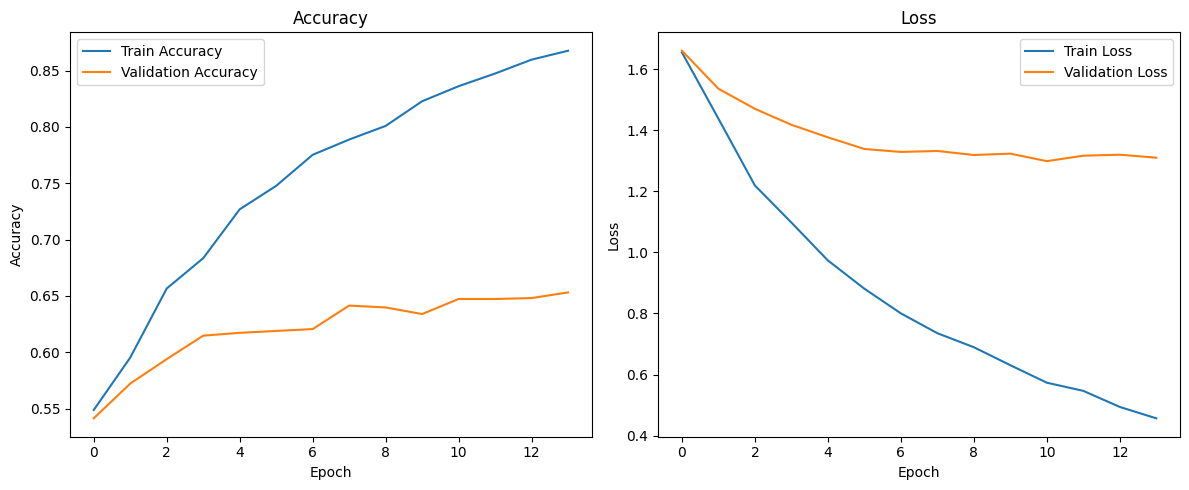

In [26]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = efficient_history.history["accuracy"]
val_acc = efficient_history.history["val_accuracy"]

loss = efficient_history.history["loss"]
val_loss = efficient_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 💡 EfficientNetB0 (Frozen) - Performance & Interpretation

EfficientNetB0 clearly outperforms MobileNetV2, reaching ~65.3% best validation accuracy and ~66.8% test accuracy (~+15pp lift over MobileNetV2 at ~51%).

Learning is strong and consistent early on, and although overfitting still appears, validation plateaus at a much higher level (~64-65%), meaning generalisation has improved significantly.

👉 Key takeaway:

- Backbone choice is the dominant lever
- EfficientNet provides better feature representations for fine-grained tasks

🎯 Next steps: Fine-tune top layers of EfficientNetB0

## EfficientNetB0 Fine-Tuning

In [27]:
# Show the top-level layers in the EfficientNetB0 model
for i, layer in enumerate(efficient_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_6 True
1 efficientnetb0 False
2 global_average_pooling2d_2 True
3 dense_4 True
4 dropout_2 True
5 dense_5 True


In [28]:
# Access pre-trained base model layers
efficient_base = efficient_model.layers[1]

print(efficient_base.name)
print("Number of layers in base model:", len(efficient_base.layers))

efficientnetb0
Number of layers in base model: 238


In [31]:
# Unfreeze the base model
efficient_base.trainable = True

# Selectively unfreeze layers to fine-tune
fine_tune_at = len(efficient_base.layers) - 30

# Freeze all layers before the fine-tune point
for i, layer in enumerate(efficient_base.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        # Keep BatchNorm layers frozen to prevent training instability
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Count trainable vs non-trainable weights
print("Trainable weights:", len(efficient_model.trainable_weights))
print("Non-trainable weights:", len(efficient_model.non_trainable_weights))

Trainable weights: 18
Non-trainable weights: 298


In [32]:
# Recompile the model with a lower learning rate for fine-tuning
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Early stopping callback for fine-tuning
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model with fine-tuning and early stopping
with mlflow.start_run(run_name="efficientnetb0_finetune_top30"):

    log_run_params(
        backbone="EfficientNetB0",
        stage="finetune_top30",
        frozen_base=False,
        learning_rate=FINE_TUNE_LEARNING_RATE,
        epochs=FINE_TUNE_EPOCHS,
        early_stopping=True,
        early_stopping_patience=3,
        batchnorm_frozen=True,
        fine_tune_at=fine_tune_at,
    )

    efficient_fine_tune_history = efficient_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(efficient_fine_tune_history)

    val_loss, val_accuracy = efficient_model.evaluate(val_ds, verbose=0)
    test_loss, test_accuracy = efficient_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)

    best_val_accuracy = max(efficient_fine_tune_history.history["val_accuracy"])
    best_val_loss = min(efficient_fine_tune_history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 59s 363ms/step - accuracy: 0.8661 - loss: 0.4774 - val_accuracy: 0.6489 - val_loss: 1.2959
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 354ms/step - accuracy: 0.8659 - loss: 0.4501 - val_accuracy: 0.6489 - val_loss: 1.2967
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 364ms/step - accuracy: 0.8745 - loss: 0.4299 - val_accuracy: 0.6530 - val_loss: 1.3000
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 383ms/step - accuracy: 0.8849 - loss: 0.3944 - val_accuracy: 0.6505 - val_loss: 1.3050
Validation Accuracy: 0.6489
Test Accuracy: 0.6735
Best Validation Accuracy: 0.6530
Best Validation Loss: 1.2959


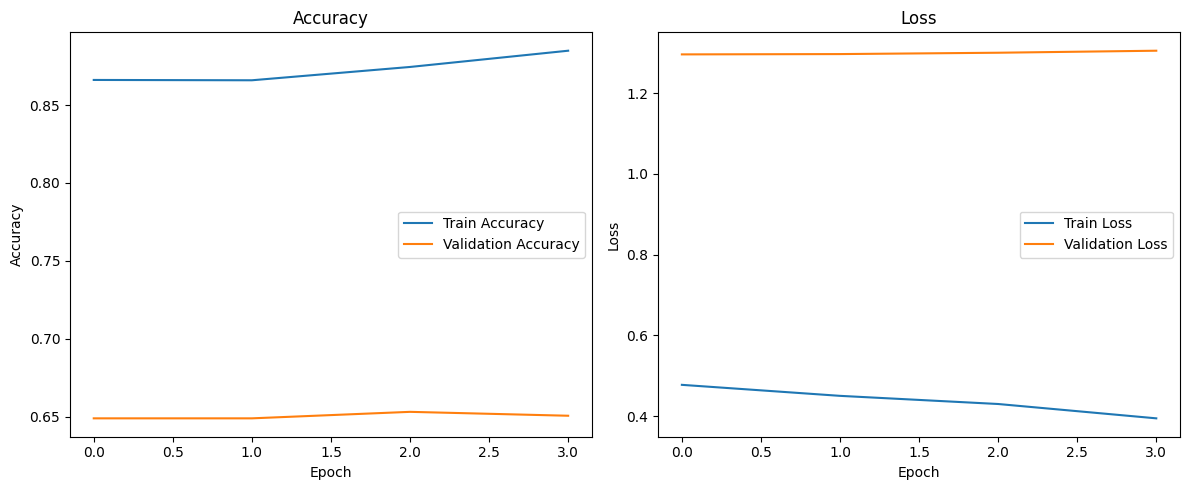

In [33]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = efficient_fine_tune_history.history["accuracy"]
val_acc = efficient_fine_tune_history.history["val_accuracy"]

loss = efficient_fine_tune_history.history["loss"]
val_loss = efficient_fine_tune_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 🙋‍♀️ Testing an alternative backbone (ResNet50)

So far, EfficientNetB0 has delivered the strongest performance, suggesting backbone choice is a key driver of results.

To validate this, I’ll test ResNet50 under the same setup (frozen backbone, identical pipeline) to see whether performance gains are specific to EfficientNet or general across stronger pretrained models.

Note: This is a controlled comparison to isolate the impact of backbone architecture.

## ResNet50V2

In [9]:
# Build and compile ResNet50 model
resnet_model = build_transfer_learning_model(
    num_classes=NUM_CLASSES,
    backbone="ResNet50",
    use_augmentation=False
)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200)       │     25,800 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,875,784 (91.08 MB)

 Trainable params: 288,072 (1.10 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the ResNet50 model and log metrics to MLflow
with mlflow.start_run(run_name="resnet50_frozen_initial"):

    log_run_params(
        backbone="ResNet50",
        stage="frozen_initial",
        frozen_base=True,
        learning_rate=LEARNING_RATE,
        epochs=15,
        early_stopping=True,
        early_stopping_patience=3
    )

    resnet_history = resnet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(resnet_history)

    val_loss, val_acc = resnet_model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = resnet_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("best_val_accuracy", max(resnet_history.history["val_accuracy"]))
    mlflow.log_metric("best_val_loss", min(resnet_history.history["val_loss"]))

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Best Validation Accuracy: {max(resnet_history.history['val_accuracy']):.4f}")
    print(f"Best Validation Loss: {min(resnet_history.history['val_loss']):.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 116s 761ms/step - accuracy: 0.0313 - loss: 4.9867 - val_accuracy: 0.1259 - val_loss: 4.1776
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 119s 797ms/step - accuracy: 0.1499 - loss: 3.7364 - val_accuracy: 0.3053 - val_loss: 3.0003
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 125s 837ms/step - accuracy: 0.2676 - loss: 2.9258 - val_accuracy: 0.3720 - val_loss: 2.5480
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 135s 903ms/step - accuracy: 0.3506 - loss: 2.4865 - val_accuracy: 0.4245 - val_loss: 2.2609
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 138s 921ms/step - accuracy: 0.3967 - loss: 2.2173 - val_accuracy: 0.4153 - val_loss: 2.1792
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 140s 935ms/step - accuracy: 0.4609 - loss: 1.9664 - val_accuracy: 0.4520 - val_loss: 2.0134
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 144s 960ms/step - accuracy: 0.4863 - loss: 1.8206 - val_accuracy: 0.4704 - val_loss: 1.9388
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.5306 - lo

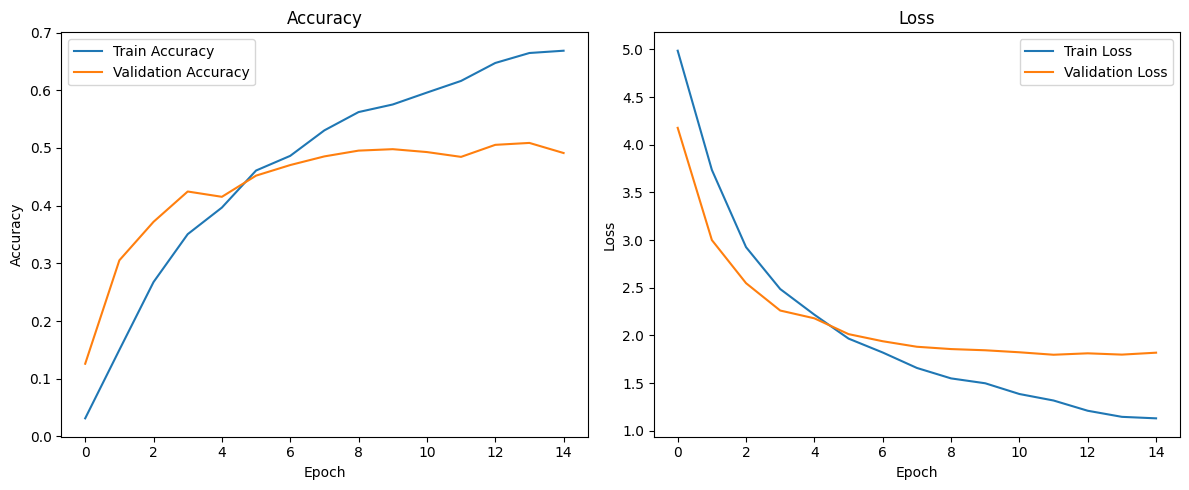

In [13]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = resnet_history.history["accuracy"]
val_acc = resnet_history.history["val_accuracy"]

loss = resnet_history.history["loss"]
val_loss = resnet_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 💡 ResNet50: No improvement over EfficientNet

ResNet50 reaches ~51% validation accuracy, broadly in line with MobileNetV2 and significantly below EfficientNetB0 (~65%).

Despite learning effectively, performance plateaus at a lower level, and overfitting appears as training progresses.

This suggests that not all pretrained backbones perform equally well for this fine-grained task. EfficientNetB0 provides stronger feature representations, while ResNet50 does not improve generalisation.

👉 Next step = deeper fine-tuning of EfficientNetB0 (more layers, lower LR)

## Conclusion

This exploration demonstrates a clear progression in model performance driven by architectural choice.

A simple CNN fails to generalise, while transfer learning enables strong performance by leveraging pretrained visual features. However, not all backbones perform equally: both MobileNetV2 and ResNet50 plateau at ~50% accuracy, while EfficientNetB0 delivers a substantial step change to ~65%.

Additional techniques - including extended training, fine-tuning, and data augmentation - improve training dynamics but do not significantly shift overall performance once a strong backbone is in place.

👉 The key finding is that feature representation quality is the dominant factor in this task. EfficientNetB0 provides more effective representations for fine-grained classification, and further gains are likely to come from deeper adaptation or higher-capacity models rather than incremental tuning.

This establishes a strong, reproducible baseline and a clear direction for future work.